# Cross-Sectional Momentum Signal — Research Notebook

End-to-end research pipeline for a **cross-sectional momentum** signal on crypto OHLCV data.
The core hypothesis: assets that have outperformed their peers over a trailing window — in raw, peer-relative, or volatility-adjusted terms — tend to keep outperforming over the holding horizon.

| Section | Topic |
|---------|-------|
| §1 | Setup — project root, imports, display options |
| §2 | Configuration — load `configs/research/momentum_signal.yaml` + DB engine |
| §3 | Data — load universe & OHLCV panel |
| §4 | Signal Pipeline — build signal, feature panels & forward returns |
| §5 | IC Analysis — per-feature IC / t-stat across core, relative & vol-adjusted families |
| §6 | Diagnostics — IC distribution, rolling IC, coverage, quantiles |
| §7 | Backtest — long/short PnL, cost stress, legs, benchmark correlation |
| §8 | Execution & Events — rolling Sharpe, execution delay, extreme-event filter |
| §9 | Robustness — horizon × skip × holding × transform × universe grid; train/test IC |
| §10 | Interpretation — checklist & summary |

All timestamps are **UTC**; run cells top to bottom (later sections reuse panels built earlier).

**Dependencies:** `cs_momentum`, `momentum_eval`, `panel_io`, `research_config`; a populated Postgres DB (OHLCV + universe tables).

## §1 Setup

Locate the project root (`src/` + `configs/`), add it to `sys.path`, and import the momentum signal builders and `momentum_eval` evaluation helpers.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "configs").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root(Path.cwd().resolve())
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common.db import make_engine
from src.common.research_config import load_research_settings
from src.data.panel_io import fetch_ohlcv_long, list_universe_symbols
from src.signals.cs_momentum import (
    apply_universe_mask,
    build_feature_panels,
    build_momentum_signal,
    build_selected_momentum_signal,
    compute_forward_returns,
    select_momentum_feature_panel,
)
from src.research.momentum_eval import (
    compute_ic_series,
    compute_ic_decay_heatmap,
    plot_ic_decay_heatmap,
    quantile_analysis,
    ic_summary,
    long_short_leg_returns,
    market_correlation,
    rolling_mean,
    rolling_sharpe,
    run_light_backtest,
)

pd.options.display.float_format = "{:.6f}".format

## §2 Configuration

Load research parameters from `configs/research/momentum_signal.yaml` and open the DB engine. Key knobs: signal timeframe, lookback and skip windows, cross-sectional transform, fee/spread assumptions, the feature-horizon and holding-period grids, and the train/test split date.

In [2]:
settings = load_research_settings("configs/research/momentum_signal.yaml")
engine = make_engine(settings)

settings_preview_keys = [
    "signal_timeframe",
    "rebalance_every_n_bars",
    "holding_period_bars",
    "momentum_lookback_bars",
    "momentum_skip_bars",
    "cross_sectional_transform",
    "log_returns",
    "residual_space",
    "fee_bps",
    "half_spread_bps",
    "feature_horizons_bars",
    "momentum_skip_grid_bars",
    "holding_period_grid_bars",
    "universe_top_n_grid",
    "train_split_date",
]

{k: settings[k] for k in settings_preview_keys}

{'signal_timeframe': '24h',
 'rebalance_every_n_bars': 1,
 'holding_period_bars': 20,
 'momentum_lookback_bars': 30,
 'momentum_skip_bars': 1,
 'cross_sectional_transform': 'rank',
 'log_returns': True,
 'residual_space': 'log',
 'fee_bps': 40.0,
 'half_spread_bps': 1.0,
 'feature_horizons_bars': [5, 10, 20, 40, 60],
 'momentum_skip_grid_bars': [1, 2, 3],
 'holding_period_grid_bars': [1, 3, 5, 10, 14, 21, 30, 40],
 'universe_top_n_grid': [10, 20],
 'train_split_date': Timestamp('2022-06-30 23:59:59+0000', tz='UTC')}

## §3 Data

Pull the **monthly rebalance universe** (rank-filtered liquid names) and long-format OHLCV for the research date range. This is the only cell that hits the database; all downstream sections work in-memory on `df_long`.

In [3]:
if settings.get("use_monthly_universe", True):
    universe_df = list_universe_symbols(
        engine,
        as_of_date=None,
        top_n=settings.get("max_assets") or settings.get("top_n"),
    )
    universe_df["rebalance_date"] = pd.to_datetime(universe_df["rebalance_date"], utc=True)
    universe_df = universe_df[
        (universe_df["rebalance_date"] >= settings["data_start_date"].normalize())
        & (universe_df["rebalance_date"] <= settings["data_end_date"].normalize())
    ]
    symbols = sorted(universe_df["symbol"].unique().tolist())
else:
    universe_df = None
    symbols = None

df_long = fetch_ohlcv_long(
    engine,
    start_ts=settings["data_start_date"],
    end_ts=settings["data_end_date"],
    symbols=symbols,
)

print(
    f"rows={len(df_long):,}, symbols={df_long['symbol'].nunique() if not df_long.empty else 0}, "
    f"monthly_points={0 if universe_df is None else universe_df['rebalance_date'].nunique()}"
)
df_long.head()

rows=1,704,347, symbols=64, monthly_points=43


,ts,symbol,open,high,low,close,volume,trades,dollar_volume
0,2020-10-01 00:00:00+00:00,ADA/USD,0.101470,0.103027,0.101280,0.102487,560347.337848,76,57428.317614
1,2020-10-01 00:00:00+00:00,ALGO/USD,0.346680,0.348180,0.344000,0.346350,27848.415930,31,9645.298857
2,2020-10-01 00:00:00+00:00,ATOM/USD,5.375300,5.448400,5.375300,5.423300,520.910352,19,2825.053111
3,2020-10-01 00:00:00+00:00,BAT/USD,0.241720,0.241850,0.241720,0.241850,6992.920526,4,1691.237829
4,2020-10-01 00:00:00+00:00,BCH/USD,228.100000,228.600000,228.100000,228.200000,148.447284,39,33875.670261


## §4 Signal Pipeline

Build the momentum signal and supporting panels in sequence:

1. `build_momentum_signal` — resample OHLCV to the signal timeframe, apply the monthly universe mask, and cross-sectionally rank/z-score.
2. `compute_forward_returns` — the prediction target for IC and backtest, matched to the selected holding period.
3. `build_feature_panels` — core, relative, and vol-adjusted feature families for the IC comparison in §5.

The resulting wide panels (`signal`, `close_wide`, `universe_mask`) are reused by all downstream sections.

In [4]:
signal_pack = build_momentum_signal(
    df_long=df_long,
    signal_timeframe=settings["signal_timeframe"],
    momentum_lookback_bars=settings["momentum_lookback_bars"],
    momentum_skip_bars=settings["momentum_skip_bars"],
    universe_df=universe_df,
    cross_sectional_transform=settings["cross_sectional_transform"],
    min_assets_per_timestamp=settings["min_assets_per_timestamp"],
    log_returns=settings["log_returns"],
    rebalance_every_n_bars=settings["rebalance_every_n_bars"],
)

signal = signal_pack["signal"]
close_wide = signal_pack["close_wide"]
universe_mask = signal_pack["universe_mask"]

# Features and forward returns share the signal-timeframe panel so that the
# IC analysis is on the same cadence and universe as the actual backtest.
fwd_ret = compute_forward_returns(
    close_wide,
    holding_period_bars=settings["holding_period_bars"],
    log_returns=settings["log_returns"],
)

feature_pack = build_feature_panels(
    close_wide=close_wide,
    horizons=settings["feature_horizons_bars"],
    benchmark_symbol=settings["benchmark_symbol"],
    vol_window_bars=settings["vol_window_bars"],
    log_returns=settings["log_returns"],
    residual_space=settings["residual_space"],
    universe_mask=universe_mask,
    skip_bars=settings["momentum_skip_bars"],
)

universe_fwd_ret = apply_universe_mask(fwd_ret, universe_mask)
xsec_universe_fwd_ret = universe_fwd_ret.sub(universe_fwd_ret.mean(axis=1), axis=0)

# Reference value kept for display only. Downstream cells use:
#   - Feature scan (bar-by-bar IC):  max(H, R) - 1  per feature
#   - Selected signal (D-subsampled IC):  (max(H, R) - 1) // D
# where R is the feature horizon / signal lookback.
baseline_nw_lag = max(
    int(settings["holding_period_bars"]),
    int(settings["momentum_lookback_bars"]),
) - 1

{
    "signal_shape": signal.shape,
    "close_wide_shape": close_wide.shape,
    "universe_fwd_ret_shape": universe_fwd_ret.shape,
    "baseline_nw_lag": baseline_nw_lag,
}

{'signal_shape': (1369, 64),
 'close_wide_shape': (1369, 64),
 'universe_fwd_ret_shape': (1369, 64),
 'baseline_nw_lag': 29}

## §5 IC Analysis

Build a comparison table of mean IC and NW-adjusted t-stat across the core, relative, and vol-adjusted feature families, then select the best-performing feature as the working signal for the rest of the notebook.

Newey-West lag accounts for overlapping forward returns, lookback windows, and rebalance decimation.

In [5]:
feature_rows = []
min_assets = settings["min_assets_per_timestamp"]
_H_scan = int(settings["holding_period_bars"])

# Features in this scan are raw (no rebalance decimation), so the NW lag only
# needs to cover forward-return overlap (H) and signal-lookback overlap (R=horizon).
# Per-feature lag: max(H, horizon) - 1.
for horizon in settings["feature_horizons_bars"]:
    feature_nw_lag = max(_H_scan, int(horizon)) - 1

    core_panel = apply_universe_mask(feature_pack["core_returns"][horizon], universe_mask)
    core_ic = compute_ic_series(core_panel, universe_fwd_ret, min_assets=min_assets)
    core_stats = ic_summary(core_ic, nw_lag=feature_nw_lag)
    feature_rows.append(
        {
            "feature": f"core_ret_{horizon}bar",
            "mean_ic": core_stats["mean_ic"],
            "t_stat_ic": core_stats["t_stat_ic"],
            "t_stat_ic_nw": core_stats["t_stat_ic_nw"],
        }
    )

    rel_panels = feature_pack["relative_features"][horizon]
    for rel_name, rel_panel in rel_panels.items():
        rel_ic = compute_ic_series(
            apply_universe_mask(rel_panel, universe_mask),
            xsec_universe_fwd_ret,
            min_assets=min_assets,
        )
        rel_stats = ic_summary(rel_ic, nw_lag=feature_nw_lag)
        feature_rows.append(
            {
                "feature": f"{rel_name}_{horizon}bar",
                "mean_ic": rel_stats["mean_ic"],
                "t_stat_ic": rel_stats["t_stat_ic"],
                "t_stat_ic_nw": rel_stats["t_stat_ic_nw"],
            }
        )

    vol_panels = feature_pack["vol_adjusted_features"][horizon]
    for vol_name in ["return_over_vol", "zscored_return"]:
        vol_ic = compute_ic_series(
            apply_universe_mask(vol_panels[vol_name], universe_mask),
            universe_fwd_ret,
            min_assets=min_assets,
        )
        vol_stats = ic_summary(vol_ic, nw_lag=feature_nw_lag)
        feature_rows.append(
            {
                "feature": f"{vol_name}_{horizon}bar",
                "mean_ic": vol_stats["mean_ic"],
                "t_stat_ic": vol_stats["t_stat_ic"],
                "t_stat_ic_nw": vol_stats["t_stat_ic_nw"],
            }
        )

feature_ic_table = pd.DataFrame(feature_rows).sort_values("mean_ic", ascending=False)
feature_ic_table.head(20)

,feature,mean_ic,t_stat_ic,t_stat_ic_nw
19,zscored_return_40bar,0.027473,3.278934,1.469203
14,zscored_return_20bar,0.017832,2.135160,1.018519
2,minus_benchmark_5bar,0.006874,0.750989,0.450653
1,minus_xsec_mean_5bar,0.006874,0.750989,0.450653
0,core_ret_5bar,0.006874,0.750989,0.450653
7,minus_benchmark_10bar,0.006119,0.698039,0.299127
5,core_ret_10bar,0.006119,0.698039,0.299127
6,minus_xsec_mean_10bar,0.006119,0.698039,0.299127
12,minus_benchmark_20bar,-0.001210,-0.130256,-0.044397
11,minus_xsec_mean_20bar,-0.001210,-0.130256,-0.044397


### IC Decay Heatmap — Signal × Holding Period

This heatmap sweeps candidate signals across a grid of holding periods and reports the Newey-West-adjusted IC t-stat for each. A signal that holds a high t-stat at longer holding periods is more persistent and tolerates slower (cheaper) rebalancing; one whose t-stat collapses quickly only works at short horizons, where turnover costs bite.

**Newey-West lag.** Overlapping windows induce serial correlation in the IC series, so the iid t-stat is too optimistic. Two IC observations stay correlated as long as they share *either* forward-return data (up to `H − 1` bars apart) *or* signal-lookback data (up to `R − 1` bars apart), so the binding truncation lag is `max(H, R) − 1` — the *larger* of the two overlaps, not their sum. Using `nw_lag = 0` would understate the standard error and inflate the t-stat at longer horizons.

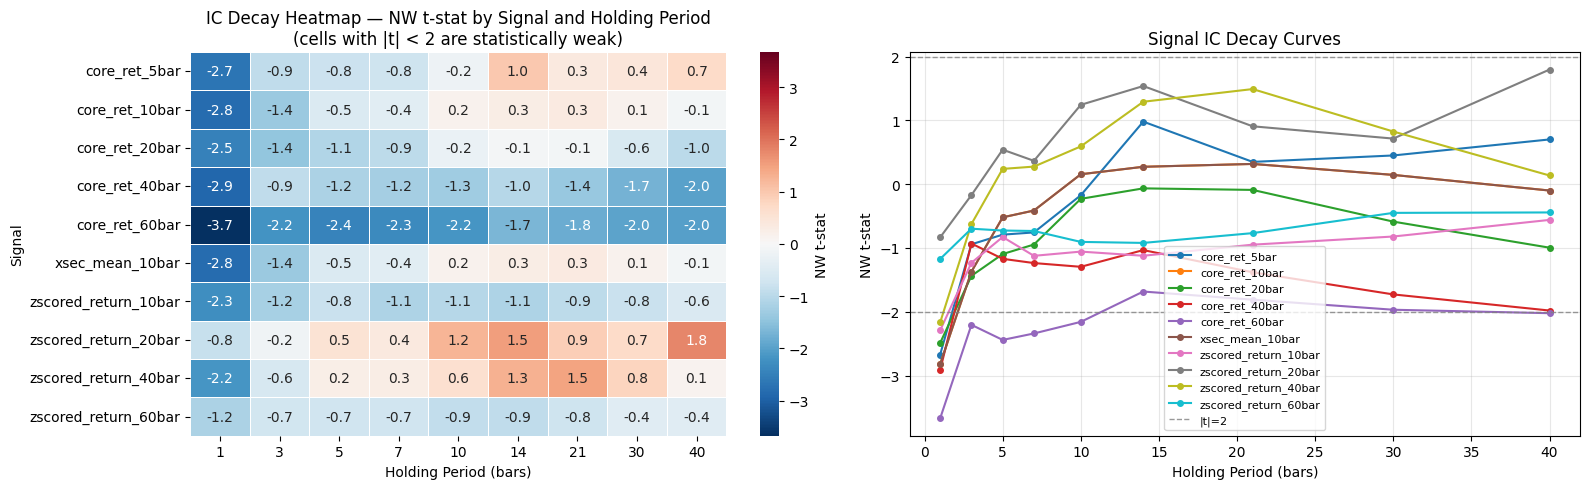

Signal                    | Peak hold |   Peak t |  t @ h=1 | Zero-cross hold
------------------------------------------------------------------------
core_ret_5bar             |        14 |     0.98 |    -2.67 | ~1
core_ret_10bar            |        21 |     0.32 |    -2.82 | ~1
core_ret_20bar            |        14 |    -0.07 |    -2.49 | ~1
core_ret_40bar            |         3 |    -0.93 |    -2.91 | ~1
core_ret_60bar            |        14 |    -1.68 |    -3.67 | ~1
xsec_mean_10bar           |        21 |     0.32 |    -2.82 | ~1
zscored_return_10bar      |        40 |    -0.56 |    -2.29 | ~1
zscored_return_20bar      |        40 |     1.80 |    -0.83 | ~1
zscored_return_40bar      |        21 |     1.49 |    -2.17 | ~1
zscored_return_60bar      |        40 |    -0.44 |    -1.17 | ~1


In [6]:
holding_period_grid = [1, 3, 5, 7, 10, 14, 21, 30, 40]

# Adjust horizons and signals to match settings["feature_horizons_bars"] if needed.
candidate_signals = {
    "core_ret_5bar":  feature_pack["core_returns"][5],
    "core_ret_10bar": feature_pack["core_returns"][10],
    "core_ret_20bar": feature_pack["core_returns"][20],
    "core_ret_40bar": feature_pack["core_returns"][40],
    "core_ret_60bar": feature_pack["core_returns"][60],
    "xsec_mean_10bar": feature_pack["relative_features"][10]["minus_xsec_mean"],
    "zscored_return_10bar": feature_pack["vol_adjusted_features"][10]["zscored_return"],
    "zscored_return_20bar": feature_pack["vol_adjusted_features"][20]["zscored_return"],
    "zscored_return_40bar": feature_pack["vol_adjusted_features"][40]["zscored_return"],
    "zscored_return_60bar": feature_pack["vol_adjusted_features"][60]["zscored_return"],
}
candidate_signals = {k: apply_universe_mask(v, universe_mask) for k, v in candidate_signals.items()}

# Feature lookback for each signal — drives NW lag = max(feature_horizon, h) - 1.
feature_horizons = {
    "core_ret_5bar":  5,
    "core_ret_10bar": 10,
    "core_ret_20bar": 20,
    "core_ret_40bar": 40,
    "core_ret_60bar": 60,
    "xsec_mean_10bar": 10,
    "zscored_return_10bar": 10,
    "zscored_return_20bar": 20,
    "zscored_return_40bar": 40,
    "zscored_return_60bar": 60,
}

t_stat_heatmap, mean_ic_heatmap = compute_ic_decay_heatmap(
    candidate_signals=candidate_signals,
    close_wide=close_wide,
    holding_period_grid=holding_period_grid,
    log_returns=settings["log_returns"],
    min_assets=settings["min_assets_per_timestamp"],
    feature_horizons=feature_horizons,
)

plot_ic_decay_heatmap(t_stat_heatmap)

In [7]:
# ---- Select signal and holding period based on IC decay heatmap above -------
feature_family = "vol_adjusted"  # baseline | core | relative | vol_adjusted
feature_horizon = 20
relative_feature = "minus_xsec_mean"  # for feature_family="relative"
vol_feature = "zscored_return"  # for feature_family="vol_adjusted"
apply_xsec_transform = True
apply_rebalance_decimation_flag = True
selected_holding_period = 14

fwd_ret = compute_forward_returns(
    close_wide, holding_period_bars=selected_holding_period, log_returns=settings["log_returns"]
)

raw_panel, signal_label = select_momentum_feature_panel(
    feature_pack=feature_pack,
    baseline_signal=signal_pack["raw_signal"],
    available_horizons=settings["feature_horizons_bars"],
    feature_family=feature_family,
    feature_horizon=feature_horizon,
    relative_feature=relative_feature,
    vol_feature=vol_feature,
)

signal = build_selected_momentum_signal(
    raw_panel=raw_panel,
    universe_mask=universe_mask,
    cross_sectional_transform=settings["cross_sectional_transform"],
    min_assets_per_timestamp=settings["min_assets_per_timestamp"],
    rebalance_every_n_bars=settings["rebalance_every_n_bars"],
    apply_xsec_transform=apply_xsec_transform,
    apply_rebalance_decimation_flag=apply_rebalance_decimation_flag,
)

_H = int(selected_holding_period)
_D = int(settings["rebalance_every_n_bars"])
_R = int(feature_horizon) if feature_family != "baseline" else int(settings["momentum_lookback_bars"])

signal_for_ic = signal.iloc[::_D] if (apply_rebalance_decimation_flag and _D > 1) else signal
fwd_ret_for_ic = fwd_ret.reindex(signal_for_ic.index)

# NW lag is expressed in units of the subsampled IC series (observations D bars apart).
# Two observations L steps apart share fwd_ret data while L*D < H (forward-return overlap)
# and signal data while L*D < R (signal-lookback overlap).
# Last overlapping lag: max((H-1)//D, (R-1)//D) = (max(H, R) - 1) // D.
# Note: D does NOT appear as an additive term — once subsampled, within-window
# duplicate bars no longer exist in the series, and D is already in the denominator.
signal_nw_lag = (max(_H, _R) - 1) // _D if (apply_rebalance_decimation_flag and _D > 1) else (max(_H, _R) - 1)

baseline_ic = compute_ic_series(signal_for_ic, fwd_ret_for_ic, min_assets=min_assets)
baseline_ic_summary = ic_summary(baseline_ic, nw_lag=signal_nw_lag)

# Coverage: forward-fill preserves NaN structure, so mean over subsampled = mean over full.
# Turnover: full signal has D-1 zero-diff bars per rebalance window, making the per-bar
# average D× smaller than the per-rebalance average. Use subsampled for a meaningful metric.
coverage = signal_for_ic.notna().sum(axis=1)
turnover_proxy = 0.5 * signal_for_ic.fillna(0.0).diff().abs().sum(axis=1)

summary = {
    "signal_label": signal_label,
    "selected_holding_period": selected_holding_period,
    **baseline_ic_summary,
    "avg_assets_per_ts": float(coverage.mean()),
    "avg_turnover_proxy": float(turnover_proxy.mean(skipna=True)),
}

summary

{'signal_label': 'zscored_return_20bar',
 'selected_holding_period': 14,
 'n_obs': 1232,
 'mean_ic': 0.026683449482278944,
 'median_ic': 0.028571428571428574,
 'std_ic': 0.2969918881354379,
 't_stat_ic': 3.1535719094522365,
 't_stat_ic_nw': 1.5382762738969764,
 'nw_lag': 19,
 'p05_ic': -0.4611236802413273,
 'p95_ic': 0.5375708502024292,
 'avg_assets_per_ts': 14.37399561723886,
 'avg_turnover_proxy': 1.071169659038875}

## §6 Diagnostics

Visual and tabular checks on the **selected signal**:

- IC histogram and time series with rolling mean
- Universe coverage (when asset count drops below `min_assets_per_timestamp`, the strategy is flat)
- Quantile portfolio forward returns and monotonicity correlation

signal_label               zscored_return_20bar
selected_holding_period                      14
n_obs                                      1232
mean_ic                                0.026683
median_ic                              0.028571
std_ic                                 0.296992
t_stat_ic                              3.153572
t_stat_ic_nw                           1.538276
nw_lag                                       19
p05_ic                                -0.461124
p95_ic                                 0.537571
avg_assets_per_ts                     14.373996
avg_turnover_proxy                     1.071170
dtype: object

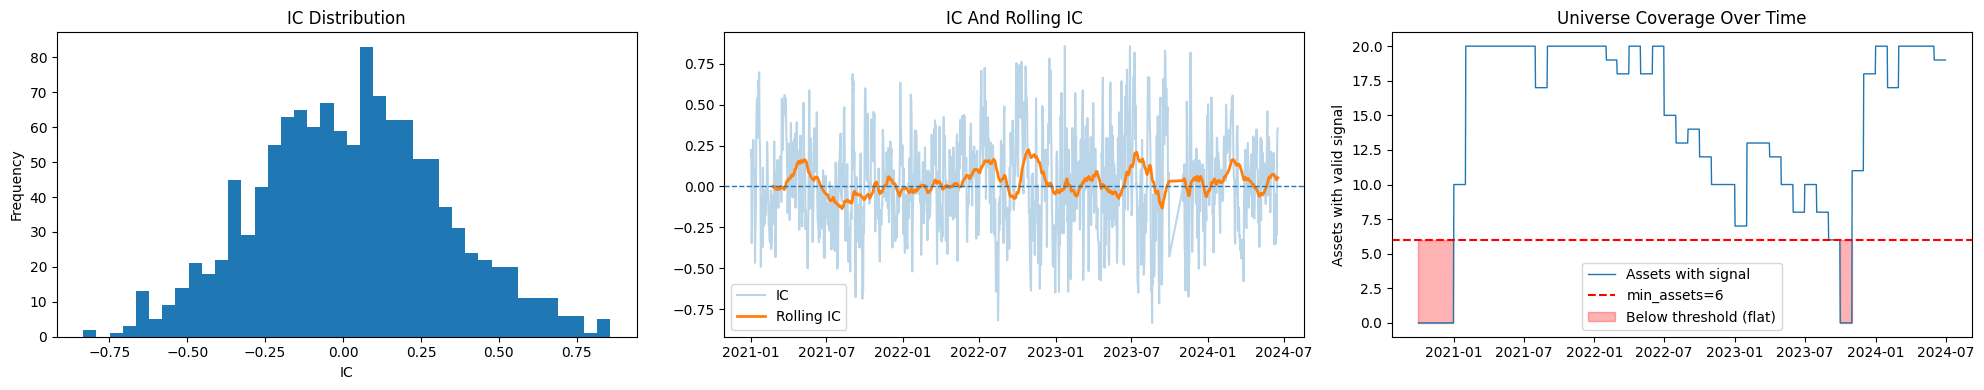

In [8]:
rolling_ic = rolling_mean(baseline_ic, settings["rolling_window_bars"])

fig, axes = plt.subplots(1, 3, figsize=(20, 4))

axes[0].hist(baseline_ic.dropna(), bins=40)
axes[0].set_title("IC Distribution")
axes[0].set_xlabel("IC")
axes[0].set_ylabel("Frequency")

axes[1].plot(baseline_ic.index, baseline_ic, alpha=0.3, label="IC")
axes[1].plot(rolling_ic.index, rolling_ic, linewidth=2, label="Rolling IC")
axes[1].axhline(0.0, linestyle="--", linewidth=1)
axes[1].set_title("IC And Rolling IC")
axes[1].legend()

# Universe coverage over time. Bars below the min_assets threshold are the
# periods where the strategy was flat (e.g. October 2023 liquidity collapse).
coverage = signal.notna().sum(axis=1)
min_assets = settings["min_assets_per_timestamp"]
axes[2].plot(coverage.index, coverage, linewidth=1, label="Assets with signal")
axes[2].axhline(min_assets, linestyle="--", linewidth=1.5, color="red",
                label=f"min_assets={min_assets}")
axes[2].fill_between(coverage.index, coverage, min_assets,
                     where=(coverage < min_assets),
                     alpha=0.3, color="red", label="Below threshold (flat)")
axes[2].set_title("Universe Coverage Over Time")
axes[2].set_ylabel("Assets with valid signal")
axes[2].legend()

plt.tight_layout()

pd.Series(summary)

{'signal_label': 'zscored_return_20bar',
 'quantile_monotonicity_corr': 0.8837508008624879,
 'top_minus_bottom_mean': 0.03349119731056925}

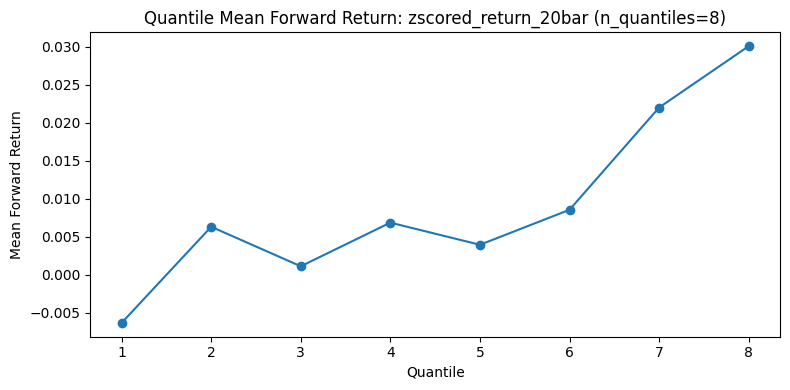

In [9]:
n_quantiles = 8
# Use rebalance-date-subsampled signal so quantile buckets reflect actual
# decision points, not forward-filled stale values between rebalances.
quantile_table, quantile_spread_ts = quantile_analysis(
    signal_for_ic,
    fwd_ret_for_ic,
    n_quantiles=n_quantiles,
    returns_are_log=settings["log_returns"],
)

if not quantile_table.empty:
    monotonicity_corr = quantile_table["quantile"].corr(quantile_table["mean_fwd_ret"])
else:
    monotonicity_corr = np.nan

fig, ax = plt.subplots(figsize=(8, 4))
if not quantile_table.empty:
    ax.plot(quantile_table["quantile"], quantile_table["mean_fwd_ret"], marker="o")
ax.set_title(
    f"Quantile Mean Forward Return: {signal_label} (n_quantiles={n_quantiles})"
)
ax.set_xlabel("Quantile")
ax.set_ylabel("Mean Forward Return")
plt.tight_layout()

{
    "signal_label": signal_label,
    "quantile_monotonicity_corr": float(monotonicity_corr) if not pd.isna(monotonicity_corr) else np.nan,
    "top_minus_bottom_mean": float(quantile_spread_ts.mean()) if len(quantile_spread_ts) else np.nan,
}

## §7 Backtest

Equal-weight top/bottom quantile long/short portfolio, gross vs net after fees and half-spread. A momentum signal should show a Sharpe that degrades gradually with cost and long/short legs that both contribute positively. Cost sensitivity is stressed via `cost_stress_multipliers`; net returns are correlated to the benchmark to check for residual beta.

(   cost_multiplier  sharpe_net  max_drawdown_net  mean_turnover  \
 0         0.000000    1.629356         -0.273451       1.533889   
 1         1.000000    1.443942         -0.317949       1.533889   
 2         1.500000    1.351130         -0.339813       1.533889   
 3         2.000000    1.258254         -0.364755       1.533889   
 
    annualized_turnover  mean_cost_per_period  total_net_return  
 0            39.990675              0.000000         49.222248  
 1            39.990675              0.006289         28.065109  
 2            39.990675              0.009433         21.081477  
 3            39.990675              0.012578         15.760728  ,
 {'signal_label': 'zscored_return_20bar',
  'long_leg_mean': 0.0021125505563221836,
  'short_leg_mean': 0.001507004054104402,
  'net_to_market_corr': 0.046593974241486896})

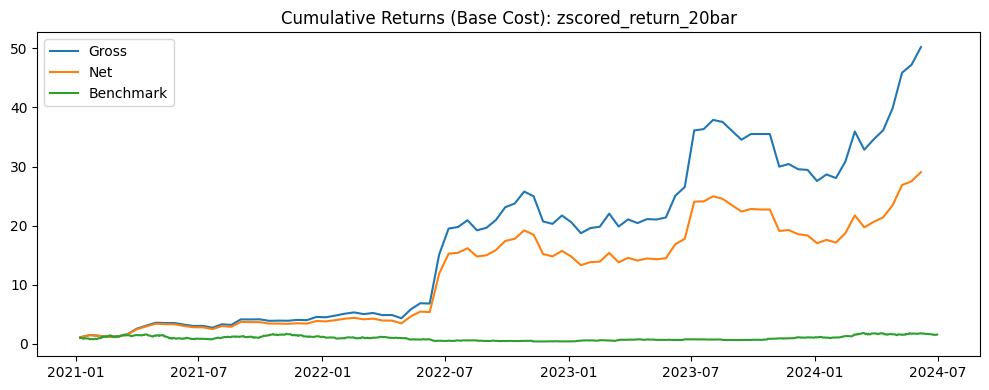

In [10]:
cost_rows = []
backtests = {}
for mult in settings["cost_stress_multipliers"]:
    bt = run_light_backtest(
        signal_wide=signal,
        forward_return_wide=fwd_ret,
        top_quantile=settings["top_quantile"],
        bottom_quantile=settings["bottom_quantile"],
        fee_bps=settings["fee_bps"] * mult,
        half_spread_bps=settings["half_spread_bps"] * mult,
        execution_delay_bars=settings["execution_delay_bars"],
        returns_are_log=settings["log_returns"],
        holding_period_bars=selected_holding_period,
    )
    backtests[mult] = bt
    cost_rows.append(
        {
            "cost_multiplier": mult,
            "sharpe_net": bt["metrics"]["sharpe_net"],
            "max_drawdown_net": bt["metrics"]["max_drawdown_net"],
            "mean_turnover": bt["metrics"]["mean_turnover"],
            "annualized_turnover": bt["metrics"]["annualized_turnover"],
            "mean_cost_per_period": bt["metrics"]["mean_cost_per_period"],
            "total_net_return": float(bt["cum_net"].iloc[-1] - 1.0),
        }
    )

cost_table = pd.DataFrame(cost_rows)
base_bt = backtests[1.0] if 1.0 in backtests else backtests[settings["cost_stress_multipliers"][0]]

long_leg, short_leg = long_short_leg_returns(
    base_bt["weights"], fwd_ret, returns_are_log=settings["log_returns"]
)

# Forward benchmark simple return aligned to the strategy's stepped P&L. Used
# for both market correlation and the extreme-event filter so that the bar at
# index t represents the move from t to t+H -- the same window over which the
# strategy realises its P&L.
benchmark_col = settings["benchmark_symbol"]
benchmark_close_wide = (
    close_wide[[benchmark_col]] if benchmark_col in close_wide.columns else close_wide
)
benchmark_fwd_log = compute_forward_returns(
    benchmark_close_wide,
    holding_period_bars=selected_holding_period,
    log_returns=settings["log_returns"],
)
if benchmark_col in close_wide.columns:
    benchmark_fwd_ret = benchmark_fwd_log[benchmark_col]
else:
    benchmark_fwd_ret = benchmark_fwd_log.mean(axis=1)
if settings["log_returns"]:
    benchmark_fwd_ret = np.exp(benchmark_fwd_ret) - 1.0

market_corr = market_correlation(base_bt["net_returns"], benchmark_fwd_ret)

if benchmark_col in benchmark_close_wide.columns:
    benchmark_px = benchmark_close_wide[benchmark_col]
else:
    benchmark_px = benchmark_close_wide.mean(axis=1)
benchmark_curve = benchmark_px.loc[benchmark_px.index >= base_bt["cum_net"].index[0]].ffill()
benchmark_curve = benchmark_curve / benchmark_curve.dropna().iloc[0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(base_bt["cum_gross"].index, base_bt["cum_gross"], label="Gross")
ax.plot(base_bt["cum_net"].index, base_bt["cum_net"], label="Net")
ax.plot(benchmark_curve.index, benchmark_curve, label="Benchmark")
ax.set_title(f"Cumulative Returns (Base Cost): {signal_label}")
ax.legend()
plt.tight_layout()

cost_table, {
    "signal_label": signal_label,
    "long_leg_mean": float(long_leg.mean()),
    "short_leg_mean": float(short_leg.mean()),
    "net_to_market_corr": market_corr,
}


## §8 Execution & Events

Stress-tests the §7 base-cost backtest for two execution risks:

- **Rolling net Sharpe** over `rolling_window_bars` — shows performance stability over time
- **Execution delay** (0 vs 1 bar) — does the edge survive a one-bar fill lag?
- **Extreme-event filter** — mean net return excluding bars where the benchmark |forward return| exceeds a quantile threshold

(   execution_delay_bars  sharpe_net  total_net_return  mean_turnover
 0                     0    1.443942         28.065109       1.533889
 1                     1    0.754494          2.538952       1.603519,
 {'signal_label': 'zscored_return_20bar',
  'extreme_event_quantile': 0.99,
  'extreme_threshold_abs_ret': 0.4267956573829075,
  'mean_net_ret_all': 0.04876850290748882,
  'mean_net_ret_excluding_extremes': 0.04876850290748882})

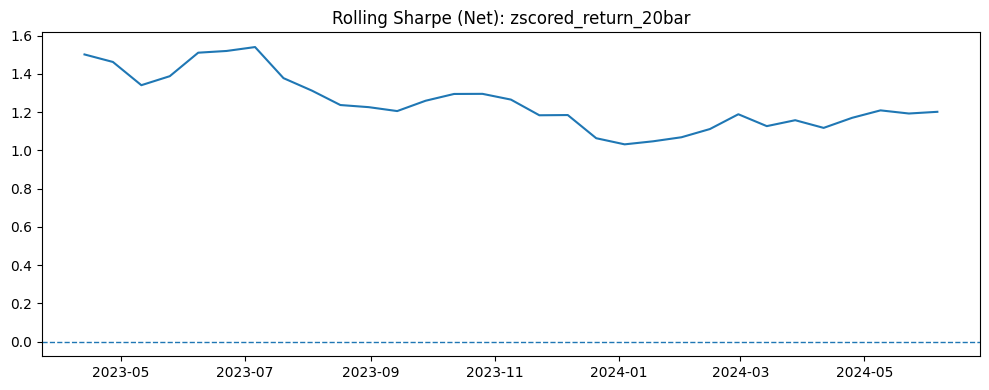

In [11]:
periods_per_year = base_bt["metrics"]["periods_per_year"]
roll_sharpe = rolling_sharpe(base_bt["net_returns"], settings["rolling_window_bars"], periods_per_year)

delay_rows = []
for delay in [0, 1]:
    bt_delay = run_light_backtest(
        signal_wide=signal,
        forward_return_wide=fwd_ret,
        top_quantile=settings["top_quantile"],
        bottom_quantile=settings["bottom_quantile"],
        fee_bps=settings["fee_bps"],
        half_spread_bps=settings["half_spread_bps"],
        execution_delay_bars=delay,
        returns_are_log=settings["log_returns"],
        holding_period_bars=selected_holding_period,
    )
    delay_rows.append(
        {
            "execution_delay_bars": delay,
            "sharpe_net": bt_delay["metrics"]["sharpe_net"],
            "total_net_return": float(bt_delay["cum_net"].iloc[-1] - 1.0),
            "mean_turnover": bt_delay["metrics"]["mean_turnover"],
        }
    )

# Use the forward benchmark return defined in the previous cell so the mask
# captures the market move during the same window as the strategy's realised
# P&L (not the trailing move into bar t).
extreme_q = float(settings["extreme_event_quantile"])
extreme_threshold = benchmark_fwd_ret.abs().quantile(extreme_q)
non_extreme_mask = benchmark_fwd_ret.abs() <= extreme_threshold
net_non_extreme = base_bt["net_returns"].where(non_extreme_mask).dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(roll_sharpe.index, roll_sharpe)
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_title(f"Rolling Sharpe (Net): {signal_label}")
plt.tight_layout()

pd.DataFrame(delay_rows), {
    "signal_label": signal_label,
    "extreme_event_quantile": extreme_q,
    "extreme_threshold_abs_ret": float(extreme_threshold),
    "mean_net_ret_all": float(base_bt["net_returns"].mean()),
    "mean_net_ret_excluding_extremes": float(net_non_extreme.mean()) if len(net_non_extreme) else np.nan,
}

## §9 Robustness

Grid search over signal horizon × JT skip × holding period × cross-sectional transform × universe size. Each combination reports mean IC, NW-adjusted t-stat, net Sharpe, and train/test IC split. Results are sorted by mean IC; the heatmap below averages over nuisance parameters to show the horizon × holding surface.

This is the slowest cell in the notebook (soon to be improved).

In [12]:
def _filter_universe(universe_input, top_n):
    if universe_input is None:
        return None
    return universe_input[universe_input["rank"] <= int(top_n)].copy()


def _train_test_stats(ic_ts, split_ts, nw_lag):
    train = ic_ts[ic_ts.index <= split_ts]
    test = ic_ts[ic_ts.index > split_ts]
    train_stats = ic_summary(train, nw_lag=nw_lag) if len(train) else None
    test_stats = ic_summary(test, nw_lag=nw_lag) if len(test) else None
    return {
        "train_mean_ic": float(train.mean()) if len(train) else np.nan,
        "test_mean_ic": float(test.mean()) if len(test) else np.nan,
        "train_t_stat_nw": train_stats["t_stat_ic_nw"] if train_stats else np.nan,
        "test_t_stat_nw": test_stats["t_stat_ic_nw"] if test_stats else np.nan,
    }


if apply_xsec_transform:
    transform_grid = settings["cross_sectional_transform_grid"]
else:
    transform_grid = [settings["cross_sectional_transform"]]

robust_rows = []
signal_horizon_grid = settings["feature_horizons_bars"]
for signal_horizon in signal_horizon_grid:
    for skip_bars in settings["momentum_skip_grid_bars"]:
        for hold in settings["holding_period_grid_bars"]:
            for transform in transform_grid:
                for top_n in settings["universe_top_n_grid"]:
                    grid_universe = _filter_universe(universe_df, top_n)
                    lookback_for_pack = (
                        signal_horizon
                        if feature_family == "baseline"
                        else settings["momentum_lookback_bars"]
                    )

                    pack = build_momentum_signal(
                        df_long=df_long,
                        signal_timeframe=settings["signal_timeframe"],
                        momentum_lookback_bars=lookback_for_pack,
                        momentum_skip_bars=skip_bars,
                        universe_df=grid_universe,
                        cross_sectional_transform=settings["cross_sectional_transform"],
                        min_assets_per_timestamp=settings["min_assets_per_timestamp"],
                        log_returns=settings["log_returns"],
                        rebalance_every_n_bars=settings["rebalance_every_n_bars"],
                    )

                    feature_pack_grid = build_feature_panels(
                        close_wide=pack["close_wide"],
                        horizons=settings["feature_horizons_bars"],
                        benchmark_symbol=settings["benchmark_symbol"],
                        vol_window_bars=settings["vol_window_bars"],
                        log_returns=settings["log_returns"],
                        residual_space=settings["residual_space"],
                        universe_mask=pack["universe_mask"],
                        skip_bars=skip_bars,
                    )

                    raw_grid, signal_label_grid = select_momentum_feature_panel(
                        feature_pack=feature_pack_grid,
                        baseline_signal=pack["raw_signal"],
                        available_horizons=settings["feature_horizons_bars"],
                        feature_family=feature_family,
                        feature_horizon=signal_horizon,
                        relative_feature=relative_feature,
                        vol_feature=vol_feature,
                    )

                    sig_grid = build_selected_momentum_signal(
                        raw_panel=raw_grid,
                        universe_mask=pack["universe_mask"],
                        cross_sectional_transform=transform,
                        min_assets_per_timestamp=settings["min_assets_per_timestamp"],
                        rebalance_every_n_bars=settings["rebalance_every_n_bars"],
                        apply_xsec_transform=apply_xsec_transform,
                        apply_rebalance_decimation_flag=apply_rebalance_decimation_flag,
                    )

                    fwd_grid = compute_forward_returns(
                        pack["close_wide"],
                        holding_period_bars=hold,
                        log_returns=settings["log_returns"],
                    )

                    # Subsample to rebalance dates (observations now D bars apart in real time).
                    _D_grid = int(settings["rebalance_every_n_bars"])
                    sig_for_ic_grid = (
                        sig_grid.iloc[::_D_grid]
                        if (apply_rebalance_decimation_flag and _D_grid > 1)
                        else sig_grid
                    )
                    fwd_for_ic_grid = fwd_grid.reindex(sig_for_ic_grid.index)

                    # NW lag in units of the subsampled series: last L where L*D < max(H, R).
                    # R = signal_horizon for non-baseline families; hold = H.
                    grid_nw_lag = (max(int(hold), int(signal_horizon)) - 1) // _D_grid if (apply_rebalance_decimation_flag and _D_grid > 1) else (max(int(hold), int(signal_horizon)) - 1)
                    ic_grid = compute_ic_series(
                        sig_for_ic_grid,
                        fwd_for_ic_grid,
                        min_assets=settings["min_assets_per_timestamp"],
                    )
                    ic_stats = ic_summary(ic_grid, nw_lag=grid_nw_lag)

                    bt_grid = run_light_backtest(
                        signal_wide=sig_grid,
                        forward_return_wide=fwd_grid,
                        top_quantile=settings["top_quantile"],
                        bottom_quantile=settings["bottom_quantile"],
                        fee_bps=settings["fee_bps"],
                        half_spread_bps=settings["half_spread_bps"],
                        execution_delay_bars=settings["execution_delay_bars"],
                        returns_are_log=settings["log_returns"],
                        holding_period_bars=hold,
                    )
                    split_stats = _train_test_stats(
                        ic_grid, settings["train_split_date"], nw_lag=grid_nw_lag
                    )

                    robust_rows.append(
                        {
                            "signal_horizon": int(signal_horizon),
                            "signal_label": signal_label_grid,
                            "relative_feature": relative_feature,
                            "vol_feature": vol_feature,
                            "skip_bars": int(skip_bars),
                            "apply_xsec_transform": bool(apply_xsec_transform),
                            "apply_rebalance_decimation": bool(apply_rebalance_decimation_flag),
                            "holding": hold,
                            # "transform": transform,
                            "top_n": top_n,
                            "nw_lag": grid_nw_lag,
                            "mean_ic": ic_stats["mean_ic"],
                            "t_stat_ic": ic_stats["t_stat_ic"],
                            "t_stat_ic_nw": ic_stats["t_stat_ic_nw"],
                            "sharpe_net": bt_grid["metrics"]["sharpe_net"],
                            "mean_turnover": bt_grid["metrics"]["mean_turnover"],
                            "annualized_turnover": bt_grid["metrics"]["annualized_turnover"],
                            **split_stats,
                        }
                    )

robustness_table = pd.DataFrame(robust_rows).sort_values(
    ["mean_ic", "sharpe_net"], ascending=False
)
robustness_table.head(20)

,signal_horizon,signal_label,relative_feature,vol_feature,skip_bars,apply_xsec_transform,apply_rebalance_decimation,holding,top_n,nw_lag,mean_ic,t_stat_ic,t_stat_ic_nw,sharpe_net,mean_turnover,annualized_turnover,train_mean_ic,test_mean_ic,train_t_stat_nw,test_t_stat_nw
142,20,zscored_return_20bar,minus_xsec_mean,zscored_return,3,True,True,40,10,39,0.040626,3.764525,1.911983,0.287071,1.446237,13.196909,0.048374,0.034217,1.658439,1.129711
126,20,zscored_return_20bar,minus_xsec_mean,zscored_return,2,True,True,40,10,39,0.040304,3.765660,1.924898,0.611547,1.397849,12.755376,0.047797,0.034106,1.705810,1.118971
104,20,zscored_return_20bar,minus_xsec_mean,zscored_return,1,True,True,14,10,19,0.040207,3.875381,1.967916,1.029486,1.501852,39.155423,0.019869,0.056394,0.653547,2.051219
110,20,zscored_return_20bar,minus_xsec_mean,zscored_return,1,True,True,40,10,39,0.039049,3.627986,1.807482,0.349306,1.521505,13.883737,0.049328,0.030545,1.683621,0.981962
120,20,zscored_return_20bar,minus_xsec_mean,zscored_return,2,True,True,14,10,19,0.037462,3.668084,1.926957,0.633696,1.568519,40.893519,0.031901,0.041887,1.105607,1.582642
127,20,zscored_return_20bar,minus_xsec_mean,zscored_return,2,True,True,40,20,39,0.036713,3.984440,1.968042,0.677340,1.496237,13.653159,0.051400,0.024563,2.407246,0.855448
106,20,zscored_return_20bar,minus_xsec_mean,zscored_return,1,True,True,21,10,20,0.036709,3.644892,1.759281,1.197050,1.730556,30.078704,0.045288,0.029811,1.376237,1.111382
143,20,zscored_return_20bar,minus_xsec_mean,zscored_return,3,True,True,40,20,39,0.036565,3.940804,1.960531,0.032648,1.552151,14.163374,0.051521,0.024192,2.432707,0.840104
111,20,zscored_return_20bar,minus_xsec_mean,zscored_return,1,True,True,40,20,39,0.034834,3.766514,1.796259,0.188554,1.544624,14.094691,0.050303,0.022038,2.291414,0.736652
136,20,zscored_return_20bar,minus_xsec_mean,zscored_return,3,True,True,14,10,19,0.032463,3.236152,1.677396,0.782789,1.561111,40.700397,0.043157,0.023952,1.510708,0.911423


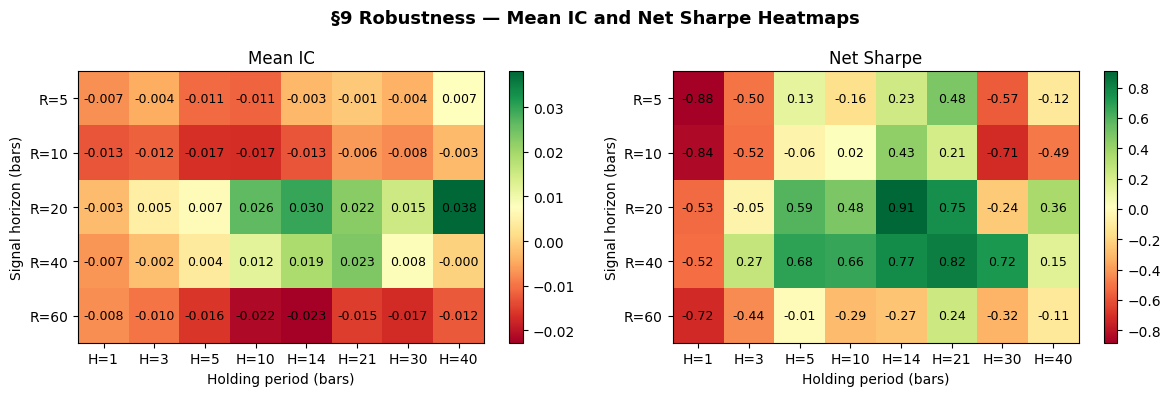

In [13]:
# Mean IC and Net Sharpe by signal horizon × holding period
# (averaged over skip / transform / universe size). A heatmap reads the
# parameter surface at a glance, where many near-identical top rows do not.
if not robustness_table.empty:
    pivot_ic = (
        robustness_table
        .groupby(["signal_horizon", "holding"])["mean_ic"]
        .mean()
        .unstack("holding")
    )
    pivot_sharpe = (
        robustness_table
        .groupby(["signal_horizon", "holding"])["sharpe_net"]
        .mean()
        .unstack("holding")
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("§9 Robustness — Mean IC and Net Sharpe Heatmaps",
                 fontsize=13, fontweight="bold")

    for ax, pivot, title, fmt in [
        (axes[0], pivot_ic,     "Mean IC",    "{:.3f}"),
        (axes[1], pivot_sharpe, "Net Sharpe", "{:.2f}"),
    ]:
        im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_yticks(range(len(pivot.index)))
        ax.set_xticklabels([f"H={c}" for c in pivot.columns])
        ax.set_yticklabels([f"R={r}" for r in pivot.index])
        ax.set_xlabel("Holding period (bars)")
        ax.set_ylabel("Signal horizon (bars)")
        ax.set_title(title)
        plt.colorbar(im, ax=ax)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                ax.text(j, i, fmt.format(pivot.values[i, j]),
                        ha="center", va="center", fontsize=9, color="black")

    plt.tight_layout()
    plt.show()

## §10 Interpretation

Use this checklist after running all cells to form a considered view on whether the signal warrants further development.

### Signal Quality
- [ ] Mean IC is positive with a NW t-stat > 1.5 (ideally > 2).
- [ ] Median IC is also positive — confirms the edge is not driven by a small number of outlier periods.

### Best Feature Family
- [ ] Note which family topped the IC table in §5 (core, relative, or vol-adjusted). Is it consistent across the §9 robustness grid?
- [ ] The vol-adjusted variants (`zscored_return`, `return_over_vol`) should outperform raw returns in high-volatility regimes.

### Holding Period Sensitivity
- [ ] The IC decay heatmap (§5) shows which horizons are most persistent. Momentum edges typically survive longer holding periods than mean-reversion edges.
- [ ] Net Sharpe and IC should agree on the best holding period — divergence suggests overfitting in one metric.

### Cost Sensitivity (§7)
- [ ] Check the Sharpe gap between 0× and 1.5× cost. A signal that collapses under 1× costs is not exploitable with market orders.
- [ ] If annualised turnover is high, consider whether a longer holding period or rebalance decimation would improve the net Sharpe.

### Execution (§8)
- [ ] Performance should survive a one-bar execution delay — if not, the signal is too fast for realistic execution at this timeframe.
- [ ] If mean net return improves substantially when large benchmark moves are excluded, consider a vol-scaling overlay.

### Train / Test (§9)
- [ ] Train IC and test IC should be in the same direction and of similar magnitude. A large drop in test IC signals overfitting of the horizon or holding parameters.

### Next Steps
- Orthogonalise with the mean-reversion signal (residualise each vs the other) before combining.
- Extend to a full multi-factor model with a risk model (e.g. PCA or factor-based covariance).
- Add execution modelling: realistic market-impact assumptions for hourly-bar signals.
- Test on alternative universes for out-of-sample validation.